Stages: ['early2cell', 'mid2cell', 'late2cell', '4cell', '8cell', '16cell', 'earlyblastula', 'midblastula', 'lateblastula']

================ early2cell ================
Nodes: 277 | Edges: 390

================ mid2cell ================
Nodes: 294 | Edges: 344

================ late2cell ================
Nodes: 281 | Edges: 227

================ 4cell ================
Nodes: 251 | Edges: 64

================ 8cell ================
Nodes: 208 | Edges: 21

================ 16cell ================
Nodes: 178 | Edges: 28

================ earlyblastula ================
Nodes: 198 | Edges: 59

================ midblastula ================
Nodes: 219 | Edges: 174

================ lateblastula ================
Nodes: 225 | Edges: 157


===== TOP 5 HUB GENES PER STAGE =====

--- early2cell ---
  Gene  Degree  Betweenness
 Aifm1      14     0.119130
 Vgll1      14     0.038762
 Xlr4c      12     0.049275
 Yipf6      12     0.035204
Cd99l2      10     0.035257

--- mid2cell ---
         Gene  

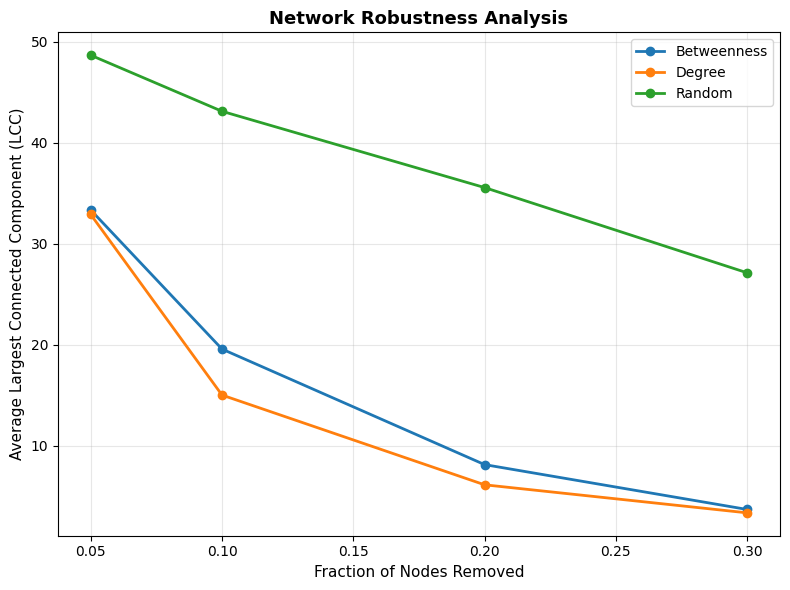

In [10]:
#loading libraries

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import random
import warnings

warnings.filterwarnings("ignore")

#loading data
file_path = "/content/X_only_all_sheets_cleaned_v3.xlsx"
xls = pd.ExcelFile(file_path)

STAGE_ORDER = [
    'early2cell', 'mid2cell', 'late2cell',
    '4cell', '8cell', '16cell',
    'earlyblastula', 'midblastula', 'lateblastula'
]

stages = [s for s in STAGE_ORDER if s in xls.sheet_names]
print("Stages:", stages)

#setting pearson coeff
MEAN_EXPR_THRESHOLD = 1.0
CORR_THRESHOLD = 0.85
TOP_HUBS = 20

#defining largest connected component
def get_lcc(G):
    if G.number_of_nodes() == 0:
        return 0
    return len(max(nx.connected_components(G), key=len))


summary_rows = []
all_hubs = []


for stage in stages:

    print(f"\n================ {stage} ================")

    df = pd.read_excel(xls, sheet_name=stage)
    df = df.dropna(subset=['Gene']).set_index('Gene')

    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != 'is_X']

    if len(numeric_cols) < 2:
        continue

    df_expr = df[numeric_cols].groupby(df.index).mean()
    df_active = df_expr[df_expr.mean(axis=1) >= MEAN_EXPR_THRESHOLD]

    if len(df_active) < 5:
        continue

    #building the network
    corr = df_active.T.corr()
    corr.index.name = 'Source'
    corr.columns.name = 'Target'

    links = corr.stack().reset_index()
    links.columns = ['Source', 'Target', 'Weight']

    links = links[
        (links['Source'] != links['Target']) &
        (links['Weight'] > CORR_THRESHOLD)
    ]

    if len(links) > 0:
        links['pair'] = links.apply(lambda x: tuple(sorted([x['Source'], x['Target']])), axis=1)
        links = links.drop_duplicates('pair')

    G = nx.from_pandas_edgelist(links, 'Source', 'Target', edge_attr='Weight')

    for g in df_active.index:
        if g not in G:
            G.add_node(g)

    if G.number_of_nodes() < 5:
        continue

    print("Nodes:", G.number_of_nodes(), "| Edges:", G.number_of_edges())

    #defining the centrality measures
    degree_dict = dict(G.degree())
    betweenness_dict = nx.betweenness_centrality(G, weight='Weight')

  #storing the top 20 hubs
    hub_df = pd.DataFrame({
        'Gene': list(G.nodes()),
        'Degree': [degree_dict[g] for g in G.nodes()],
        'Betweenness': [betweenness_dict[g] for g in G.nodes()]
    })

    hub_df = hub_df.sort_values(
        by=['Degree', 'Betweenness'],
        ascending=[False, False]
    ).reset_index(drop=True)

    top20 = hub_df.head(TOP_HUBS).copy()
    top20['Stage'] = stage
    all_hubs.append(top20)

    #progressive node removal test
    degree_ranked = sorted(degree_dict, key=degree_dict.get, reverse=True)
    betweenness_ranked = sorted(betweenness_dict, key=betweenness_dict.get, reverse=True)

    random_nodes = list(G.nodes())
    random.shuffle(random_nodes)

    fractions = [0.05, 0.1, 0.2, 0.3]

    for label, ranked_nodes in {
        "Degree": degree_ranked,
        "Betweenness": betweenness_ranked,
        "Random": random_nodes
    }.items():

        for frac in fractions:
            k = max(1, int(frac * G.number_of_nodes()))
            remove_nodes = ranked_nodes[:k]

            G_temp = G.copy()
            G_temp.remove_nodes_from(remove_nodes)

            summary_rows.append({
                "Stage": stage,
                "Method": label,
                "Fraction_Removed": frac,
                "Nodes_Removed": k,
                "Total_Nodes": G.number_of_nodes(),
                "Edges": G.number_of_edges(),
                "LCC": get_lcc(G_temp),
                "Components": nx.number_connected_components(G_temp)
            })


hubs_df = pd.concat(all_hubs, ignore_index=True)
hubs_df.to_csv("top20_hubs_all_stages.csv", index=False)

#top 5 hubs
top5_rows = []

print("\n\n===== TOP 5 HUB GENES PER STAGE =====")

for stage in hubs_df['Stage'].unique():

    sub = hubs_df[hubs_df['Stage'] == stage]

    top5 = sub.head(5).copy()
    top5_rows.append(top5)

    print(f"\n--- {stage} ---")
    print(top5[['Gene', 'Degree', 'Betweenness']].to_string(index=False))

top5_df = pd.concat(top5_rows, ignore_index=True)
top5_df.to_csv("top5_hubs_per_stage.csv", index=False)

print("\nSaved: top5_hubs_per_stage.csv")


summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("robustness_summary_all_stages.csv", index=False)

print("\nSaved: robustness_summary_all_stages.csv")


# Average across stages (cleaner visualization)
plot_df = summary_df.groupby(['Method', 'Fraction_Removed']).agg({
    'LCC': 'mean'
}).reset_index()

plt.figure(figsize=(8,6))

for method in plot_df['Method'].unique():
    sub = plot_df[plot_df['Method'] == method]
    plt.plot(sub['Fraction_Removed'], sub['LCC'], marker='o', linewidth=2, label=method)

plt.xlabel("Fraction of Nodes Removed", fontsize=11)
plt.ylabel("Average Largest Connected Component (LCC)", fontsize=11)
plt.title("Network Robustness Analysis", fontsize=13, fontweight='bold')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("final_robustness_plot.png", dpi=300)
plt.show()